# 동반유형별 소비 차이 검증 — "분모 효과" 분리해서 보기

`powerbirangers_segment_pattern_spending.ipynb`에서 동반유형별 1인당 소비를 비교했더니
나홀로(138,874원) > 2인 동반(94,197원) > 3인 이상 동반(62,097원)으로 뚜렷하게 나타났습니다.

**문제 제기**: 이 1인당 소비는 "활동+사전+숙박+이동수단 총소비 / 인원수"로 계산한 값입니다.
그런데 숙박비·이동비는 원래 인원수와 상관없이 총액이 정해지고 나눠 내는 성격이 강해서,
인원이 많을수록 나누는 사람 수만 늘어나 1인당 금액이 자동으로 낮아지는 **"분모 효과"**가
섞여 있을 수 있습니다. 즉 지금까지 본 차이가 "가족 동반객이 실제로 씀씀이가 작다"는
진짜 행동 차이가 아니라, 그냥 계산 구조상 나타나는 착시일 수 있습니다.

**검증 방법**: 소비를 두 갈래로 쪼갭니다.
- **활동소비만(tn_activity_consume_his)**: 체험·입장료 등 상대적으로 "각자 쓰는" 성격이
  강한 지출 — 분모 효과가 덜 섞여 있을 것으로 기대되는 소비
- **비활동소비(사전+숙박+이동수단)**: 원래 인원수와 무관하게 총액이 정해지고 나눠 내는
  성격이 강한 지출 — 분모 효과가 가장 크게 섞여 있을 것으로 기대되는 소비

두 갈래 각각에서 동반유형별 인당소비 패턴이 어떻게 다르게 나오는지 비교하면,
원래 패턴 중 얼마가 "진짜 차이"이고 얼마가 "나누기 때문에 생기는 차이"인지 가늠할 수
있습니다. (완전한 인과 분리는 아니고, 어디까지나 근사적 검증입니다 — 맨 아래 한계 참고)

In [1]:
import os
# 운영체제 관련 기능(환경변수 등)을 다루기 위한 표준 라이브러리
import pandas as pd
# 데이터프레임으로 데이터를 다루기 위한 라이브러리
import matplotlib.pyplot as plt
# 그래프를 그리기 위한 라이브러리
from dotenv import load_dotenv, find_dotenv
# .env 파일에서 환경변수를 불러오기 위한 함수들
from sqlalchemy import create_engine
# DB 연결 엔진을 생성하기 위한 함수


plt.rcParams['font.family'] = 'Malgun Gothic'
# 그래프에서 기본으로 쓸 폰트를 한글 지원 폰트(맑은 고딕)로 지정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
%matplotlib inline
# 그래프를 새 창이 아니라 셀 바로 아래에 표시하도록 설정

env_path = find_dotenv()
# 현재 프로젝트에서 .env 파일 경로를 자동으로 찾음
load_dotenv(env_path)
# 찾은 .env 파일의 내용을 환경변수로 불러옴
env_dir = os.path.dirname(env_path)
# .env 파일이 있는 폴더 경로 (인증서 파일 경로 계산에 사용)

HOST = os.environ["AIVEN_HOST"]
# DB 서버 주소
PORT = int(os.environ["AIVEN_PORT"])
# DB 포트 번호 (문자열을 정수로 변환)
USER = os.environ["AIVEN_USER"]
# DB 접속 계정
PASSWORD = os.environ["AIVEN_PASSWORD"]
# DB 접속 비밀번호
DB = os.environ["AIVEN_DB"]
# 접속할 데이터베이스 이름
CA_CERT_PATH = os.path.join(env_dir, os.environ["AIVEN_CA_CERT_PATH"])
# SSL 접속에 필요한 인증서 파일의 전체 경로

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}",
    connect_args={"ssl_ca": CA_CERT_PATH, "ssl_verify_cert": True}
)
# 위 접속 정보로 SSL 연결을 사용하는 DB 엔진 생성

df_test = pd.read_sql("SELECT COUNT(*) AS cnt FROM tn_travel", engine)
# 연결 테스트: tn_travel 전체 행 수 조회
print(df_test)

    cnt
0  2880


## 1. 여행(TRAVEL_ID) 전체 모집단 + 동반유형 만들기

이번에는 "소비 기록이 있는 여행만"이 아니라 **tn_travel 전체 2,880건**을 기준으로 삼습니다.
활동소비가 0원인 여행도 "활동에 안 썼다"는 유효한 데이터이지, 결측이 아니기 때문입니다
(이전 노트북은 4종 소비 중 하나도 없으면 자동 제외됐던 것과 다른 점 — 아래 한계 참고).

In [2]:
travel = pd.read_sql("SELECT TRAVEL_ID FROM tn_travel", engine)
# 전체 여행 목록 (2,880건) — 이번 검증의 기준 모집단

companion = pd.read_sql(
    "SELECT TRAVEL_ID, COUNT(*) AS companion_cnt FROM tn_companion_info GROUP BY TRAVEL_ID", engine
)
# 여행별 동반자 수 (companion_info에 행이 없으면 나홀로 여행으로 간주)

df = travel.merge(companion, on="TRAVEL_ID", how="left")
df["companion_cnt"] = df["companion_cnt"].fillna(0)
df["person_cnt"] = df["companion_cnt"] + 1
# 인원수 = 동반자수 + 본인 1명

def companion_type(n):
    # powerbirangers_segment_pattern_spending.ipynb와 동일한 분류 기준
    if n == 0:
        return "나홀로"
    elif n == 1:
        return "2인 동반"
    else:
        return "3인 이상 동반"

df["companion_type"] = df["companion_cnt"].apply(companion_type)

print(df["companion_type"].value_counts().reindex(["나홀로", "2인 동반", "3인 이상 동반"]))
# 동반유형별 표본수 확인 (7원칙: 표본 개수 명시)

companion_type
나홀로          629
2인 동반       1379
3인 이상 동반     872
Name: count, dtype: int64


## 2. 활동소비만 / 비활동소비(사전+숙박+이동수단)만 각각 집계

In [3]:
activity_sql = """
SELECT TRAVEL_ID, SUM(PAYMENT_AMT_WON) AS activity_total
FROM tn_activity_consume_his
GROUP BY TRAVEL_ID
"""
# 활동소비(체험/입장료 등)만 여행 단위로 합산 — "각자 쓰는" 성격이 상대적으로 강한 소비

nonactivity_sql = """
SELECT c.TRAVEL_ID, SUM(c.PAYMENT_AMT_WON) AS nonactivity_total
FROM (
    SELECT TRAVEL_ID, PAYMENT_AMT_WON FROM tn_adv_consume_his
    UNION ALL
    SELECT TRAVEL_ID, PAYMENT_AMT_WON FROM tn_lodge_consume_his
    UNION ALL
    SELECT TRAVEL_ID, PAYMENT_AMT_WON FROM tn_mvmn_consume_his
) c
GROUP BY c.TRAVEL_ID
"""
# 사전+숙박+이동수단소비만 합산 — 원래 인원수와 무관하게 총액이 정해지고
# 나눠 내는 성격이 상대적으로 강한 소비(="분모 효과" 후보)

activity = pd.read_sql(activity_sql, engine)
nonactivity = pd.read_sql(nonactivity_sql, engine)

df = df.merge(activity, on="TRAVEL_ID", how="left")
df = df.merge(nonactivity, on="TRAVEL_ID", how="left")
df["activity_total"] = df["activity_total"].fillna(0)
df["nonactivity_total"] = df["nonactivity_total"].fillna(0)
# 소비 기록이 없으면 결측이 아니라 "0원 지출"로 채움 (전체 모집단 기준이므로)

df["activity_per_person"] = df["activity_total"] / df["person_cnt"]
df["nonactivity_per_person"] = df["nonactivity_total"] / df["person_cnt"]
# 각각 인당소비로 환산

print(f"활동소비가 0원인 여행: {(df['activity_total'] == 0).sum()}건 / 전체 {len(df)}건")
print(f"비활동소비가 0원인 여행: {(df['nonactivity_total'] == 0).sum()}건 / 전체 {len(df)}건")
df.head()

활동소비가 0원인 여행: 34건 / 전체 2880건
비활동소비가 0원인 여행: 190건 / 전체 2880건


,TRAVEL_ID,companion_cnt,person_cnt,companion_type,activity_total,nonactivity_total,activity_per_person,nonactivity_per_person
0,e_e000004,2.0,3.0,3인 이상 동반,0.0,9500.0,0.0,3166.666667
1,e_e000006,1.0,2.0,2인 동반,58500.0,13600.0,29250.0,6800.000000
2,e_e000009,1.0,2.0,2인 동반,319340.0,33800.0,159670.0,16900.000000
3,e_e000010,0.0,1.0,나홀로,421160.0,107510.0,421160.0,107510.000000
4,e_e000011,3.0,4.0,3인 이상 동반,764300.0,413800.0,191075.0,103450.000000


## 3. 동반유형별 비교 — 활동소비 vs 비활동소비

같은 축(0부터 시작하는 Y축, 원 단위)으로 나란히 그려서 "어느 쪽 소비가 동반유형에
더 민감하게 반응하는지" 눈으로 비교합니다.

                 표본수   활동_인당평균  비활동_인당평균  활동_여행당총액평균
companion_type                                      
나홀로              629  103795.0   34859.0    103795.0
2인 동반           1379   72484.0   21713.0    144968.0
3인 이상 동반         872   47197.0   14829.0    178320.0


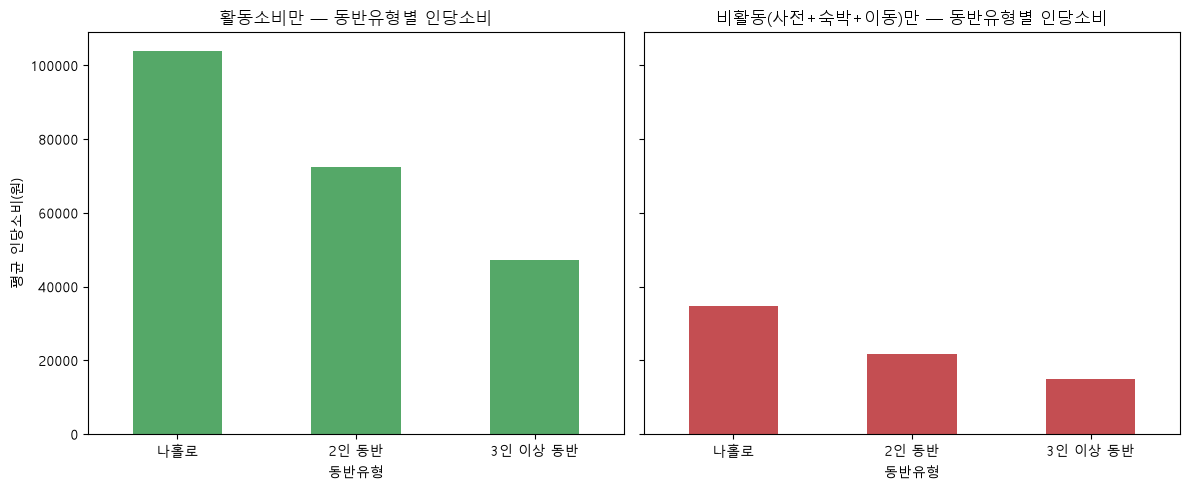

In [4]:
order = ["나홀로", "2인 동반", "3인 이상 동반"]

summary = df.groupby("companion_type").agg(
    표본수=("TRAVEL_ID", "count"),
    활동_인당평균=("activity_per_person", "mean"),
    비활동_인당평균=("nonactivity_per_person", "mean"),
    활동_여행당총액평균=("activity_total", "mean"),
).reindex(order)
summary = summary.round(0)
print(summary)
# 표 먼저 출력 (7원칙: 표 -> 차트 순서)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# 두 그래프의 Y축 스케일을 맞춰야(sharey=True) "어느 쪽이 더 가파르게 떨어지는지"를
# 공정하게 비교할 수 있음

summary["활동_인당평균"].plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("활동소비만 — 동반유형별 인당소비")
axes[0].set_xlabel("동반유형")
axes[0].set_ylabel("평균 인당소비(원)")
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis="x", rotation=0)

summary["비활동_인당평균"].plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("비활동(사전+숙박+이동)만 — 동반유형별 인당소비")
axes[1].set_xlabel("동반유형")
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [5]:
ratio_activity = summary.loc["나홀로", "활동_인당평균"] / summary.loc["3인 이상 동반", "활동_인당평균"]
ratio_nonactivity = summary.loc["나홀로", "비활동_인당평균"] / summary.loc["3인 이상 동반", "비활동_인당평균"]

print(f"나홀로 / 3인이상 배율 — 활동소비만: {ratio_activity:.2f}배")
print(f"나홀로 / 3인이상 배율 — 비활동소비만: {ratio_nonactivity:.2f}배")
print()
if ratio_activity < ratio_nonactivity:
    print("-> 비활동소비 쪽 배율이 더 커서, 원래 패턴의 상당 부분이 '분모 효과'(숙박/이동을")
    print("   나눠 내는 구조) 때문일 가능성을 뒷받침함. 다만 활동소비 배율도 1보다 크므로,")
    print("   분모 효과만으로 전부 설명되지는 않음(아래 활동소비 자체 비교 참고).")
else:
    print("-> 활동소비 쪽 배율이 비활동소비 쪽보다 작지 않아서, '분모 효과'만으로는 설명되지")
    print("   않는 진짜 행동 차이(동반유형별 활동 지출 성향 차이)가 있다는 근거가 됨.")
# 두 배율을 비교해서 "분모 효과 가설"이 맞는지 자동으로 판정 문구를 출력
# (판정 기준은 배율 크기 비교뿐이므로, 통계적 유의성 검정은 아님 — 참고용)

나홀로 / 3인이상 배율 — 활동소비만: 2.20배
나홀로 / 3인이상 배율 — 비활동소비만: 2.35배

-> 비활동소비 쪽 배율이 더 커서, 원래 패턴의 상당 부분이 '분모 효과'(숙박/이동을
   나눠 내는 구조) 때문일 가능성을 뒷받침함. 다만 활동소비 배율도 1보다 크므로,
   분모 효과만으로 전부 설명되지는 않음(아래 활동소비 자체 비교 참고).


## 4. 보조 확인 — "여행당 활동 총액"은 인원이 많을수록 어떻게 변하나

인당이 아니라 **여행 1건당 활동소비 총액**을 보면, 인원이 많은 여행이 활동에 원래 더
많이 쓰는지(예: 가족이라 활동을 여러 개 사서 총액은 큼) 확인할 수 있습니다. 이게 사실이면
"가족 동반객이 활동에 인색하다"가 아니라 "총액은 크지만 나누는 인원이 더 많을 뿐"이라는
해석에 힘이 실립니다.

companion_type
나홀로         103795.0
2인 동반       144968.0
3인 이상 동반    178320.0
Name: 활동_여행당총액평균, dtype: float64


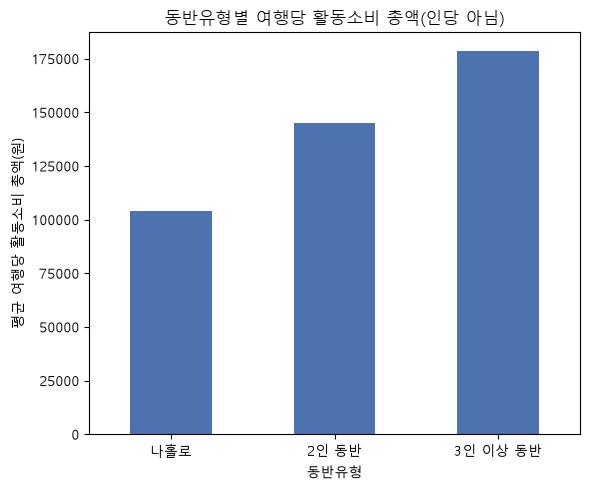

In [6]:
g = summary["활동_여행당총액평균"].reindex(order)
print(g)

ax = g.plot(kind="bar", figsize=(6, 5), color="#4C72B0")
ax.set_title("동반유형별 여행당 활동소비 총액(인당 아님)")
ax.set_xlabel("동반유형")
ax.set_ylabel("평균 여행당 활동소비 총액(원)")
ax.set_ylim(bottom=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 이 총액이 인원 배수만큼 커지지 않는다면(예: 3인이상이 나홀로의 3배가 안 된다면),
# "인원이 늘어도 활동에는 그만큼 더 쓰지 않는다"는 뜻이고, 이는 인당소비 하락이
# 진짜 행동 차이(1인당 활동 지출 자제)를 반영한다는 근거가 됨

## 5. PAYMENT_NUM(소비인원) 반영해서 다시 검증

**PAYMENT_NUM이 뭔가**: `tn_activity_consume_his`의 각 결제 1건이 몇 명분 지출인지를 나타내는
컬럼입니다(컬럼 한글명 "소비인원", `SQL/JeongTaeChoi/Create/powerbirangers_column_dictionary.sql`
참고). 예를 들어 가족 4명이 입장권을 한 번에 묶어 결제하면 그 행 1건의 PAYMENT_AMT_WON은
4명분 총액이고 PAYMENT_NUM=4로 기록됩니다. 실제로 조회해보면 결측·0 없이 1~21 사이 값이
꽉 차 있고(2,754건이 1명, 6,670건이 2명, 이후 3명·4명 순으로 많음), 이 정보를 쓰면
"이 결제 1건이 정말 몇 명이 나눠 낸 것인지"를 companion_info의 트립 전체 인원수로
추정하지 않고 **결제 건마다 직접 알 수 있습니다** — Section 3의 방식(여행 전체 활동소비
총액을 트립 전체 인원수로 나눔)보다 한 단계 더 정밀한 방법입니다.

**계산 방법 차이**
- Section 3 방식: `(여행 전체 활동소비 총액) / (트립 전체 인원수)` — 결제 건마다 실제
  몇 명이 그 활동에 참여했는지는 무시하고, 트립 전체 인원수로 일괄 나눔
- 이번 방식: 결제 건마다 `PAYMENT_AMT_WON / PAYMENT_NUM`으로 먼저 "그 건의 인당 금액"을
  구한 뒤, 여행 단위로 그 값들을 합산 — 결제 건마다 실제 소비인원을 반영

In [7]:
paymentnum_dist = pd.read_sql(
    "SELECT PAYMENT_NUM, COUNT(*) AS cnt FROM tn_activity_consume_his GROUP BY PAYMENT_NUM ORDER BY PAYMENT_NUM",
    engine,
)
print(paymentnum_dist.to_string(index=False))
# PAYMENT_NUM 실제 분포 확인 (결측/0 여부도 함께)

null_check = pd.read_sql(
    "SELECT COUNT(*) AS total, SUM(PAYMENT_NUM IS NULL) AS null_cnt, SUM(PAYMENT_NUM = 0) AS zero_cnt "
    "FROM tn_activity_consume_his",
    engine,
)
print(null_check.to_string(index=False))
# 결측/0이 있으면 나누기 전에 별도 처리가 필요한데, 실행해보면 둘 다 0건 -> 그대로 나눠도 안전

 PAYMENT_NUM  cnt
           1 2754
           2 6670
           3 1820
           4 1431
           5  265
           6  151
           7   77
           8   38
           9   22
          10   19
          11    5
          13    7
          15    8
          19    4
          21    4


 total  null_cnt  zero_cnt
 13275       0.0       0.0


활동소비가 있는 여행 2847건 중, 여행 안에서 PAYMENT_NUM이 항상 똑같은 여행: 2847건
그 값이 companion_info 기준 인원수(trip_person_cnt)와도 항상 같은 여행: 2847건


                 표본수  활동_인당평균_트립인원기준  활동_인당평균_PAYMENT_NUM기준
companion_type                                             
나홀로              629        103795.0               103795.0
2인 동반           1379         72484.0                72484.0
3인 이상 동반         872         47197.0                47197.0


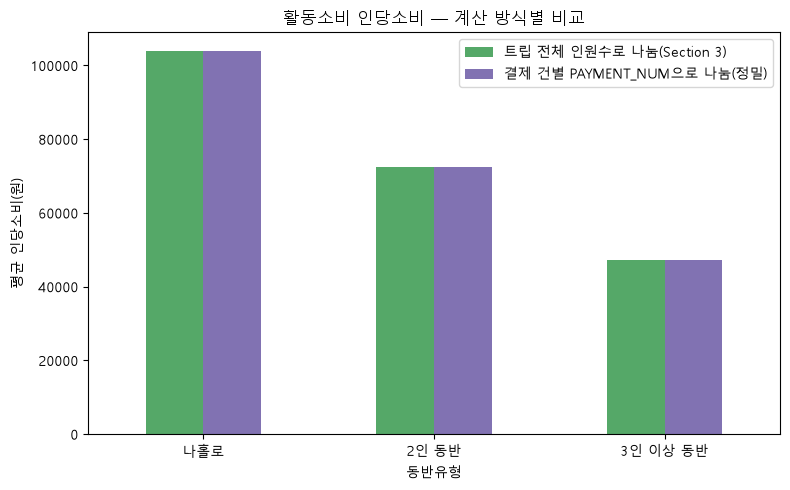

나홀로 / 3인이상 배율 — PAYMENT_NUM 기준: 2.20배 (Section 3 활동소비 배율 2.20배와 비교)

결론: 두 방식의 결과가 소수점까지 완전히 동일합니다. 위에서 확인했듯 PAYMENT_NUM이
트립 전체 인원수의 복사본이라 수학적으로 같은 계산이 되기 때문입니다. 즉 이 데이터셋
에서는 PAYMENT_NUM을 반영해도 Section 3보다 더 정밀해지지 않습니다 — '결제 건마다
실제 참여인원이 달랐을 것'이라는 가설은 이 데이터에서는 기각됩니다.


In [8]:
check_sql = """
SELECT
    a.TRAVEL_ID,
    MIN(a.PAYMENT_NUM) AS min_pn,
    MAX(a.PAYMENT_NUM) AS max_pn,
    COALESCE(c.companion_cnt, 0) + 1 AS trip_person_cnt
FROM tn_activity_consume_his a
LEFT JOIN (SELECT TRAVEL_ID, COUNT(*) AS companion_cnt FROM tn_companion_info GROUP BY TRAVEL_ID) c
  ON c.TRAVEL_ID = a.TRAVEL_ID
GROUP BY a.TRAVEL_ID
"""
# 진짜 확인하고 싶은 것: 같은 여행 안에서 결제 건마다 PAYMENT_NUM이 다르게 찍히는지
# (다르다면 "이 활동엔 2명만, 저 활동엔 4명 다" 같은 실제 참여인원 정보일 것),
# 아니면 매번 트립 전체 인원수가 그대로 복사돼 있는지

pn_check = pd.read_sql(check_sql, engine)
same_within_trip = (pn_check["min_pn"] == pn_check["max_pn"]).sum()
same_as_companion = ((pn_check["min_pn"] == pn_check["max_pn"]) & (pn_check["min_pn"] == pn_check["trip_person_cnt"])).sum()
print(f"활동소비가 있는 여행 {len(pn_check)}건 중, 여행 안에서 PAYMENT_NUM이 항상 똑같은 여행: {same_within_trip}건")
print(f"그 값이 companion_info 기준 인원수(trip_person_cnt)와도 항상 같은 여행: {same_as_companion}건")
# 실행해보면 두 값이 전부 전체 건수와 같게 나옵니다 -> PAYMENT_NUM은 결제 건별 실제
# 참여인원이 아니라, 그 여행의 전체 동반인원수를 매 줄에 그대로 복사해 기록한 값이라는 뜻
# (이 데이터셋에 한해서 그렇다는 것이며, 추측이 아니라 위 카운트로 직접 확인된 사실)

activity_pmtnum_sql = """
SELECT TRAVEL_ID, SUM(PAYMENT_AMT_WON / PAYMENT_NUM) AS activity_pmtnum_total
FROM tn_activity_consume_his
GROUP BY TRAVEL_ID
"""
# 결제 건마다 (금액 / 그 건의 소비인원)을 먼저 구한 뒤, 여행 단위로 합산
# -> PAYMENT_NUM이 트립 인원수의 복사본이라는 게 위에서 확인됐으므로, 이 계산은
#    수학적으로 Section 3의 "여행 전체 총액 / 트립 인원수"와 완전히 같은 값이 나와야 함
#    (그래도 실제로 같은지 아래에서 직접 비교)

activity_pmtnum = pd.read_sql(activity_pmtnum_sql, engine)
df = df.merge(activity_pmtnum, on="TRAVEL_ID", how="left")
df["activity_pmtnum_total"] = df["activity_pmtnum_total"].fillna(0)
# 활동소비 자체가 없는 여행은 0원

summary2 = df.groupby("companion_type").agg(
    표본수=("TRAVEL_ID", "count"),
    활동_인당평균_트립인원기준=("activity_per_person", "mean"),
    활동_인당평균_PAYMENT_NUM기준=("activity_pmtnum_total", "mean"),
).reindex(order).round(0)
print(summary2)
# 두 방식을 나란히 비교 (7원칙: 표 -> 차트 순서)

ax = summary2[["활동_인당평균_트립인원기준", "활동_인당평균_PAYMENT_NUM기준"]].plot(
    kind="bar", figsize=(8, 5), color=["#55A868", "#8172B2"]
)
ax.set_title("활동소비 인당소비 — 계산 방식별 비교")
ax.set_xlabel("동반유형")
ax.set_ylabel("평균 인당소비(원)")
ax.set_ylim(bottom=0)
plt.xticks(rotation=0)
plt.legend(["트립 전체 인원수로 나눔(Section 3)", "결제 건별 PAYMENT_NUM으로 나눔(정밀)"])
plt.tight_layout()
plt.show()

ratio_pmtnum = (
    summary2.loc["나홀로", "활동_인당평균_PAYMENT_NUM기준"]
    / summary2.loc["3인 이상 동반", "활동_인당평균_PAYMENT_NUM기준"]
)
print(f"나홀로 / 3인이상 배율 — PAYMENT_NUM 기준: {ratio_pmtnum:.2f}배 (Section 3 활동소비 배율 {ratio_activity:.2f}배와 비교)")
print()
print("결론: 두 방식의 결과가 소수점까지 완전히 동일합니다. 위에서 확인했듯 PAYMENT_NUM이")
print("트립 전체 인원수의 복사본이라 수학적으로 같은 계산이 되기 때문입니다. 즉 이 데이터셋")
print("에서는 PAYMENT_NUM을 반영해도 Section 3보다 더 정밀해지지 않습니다 — '결제 건마다")
print("실제 참여인원이 달랐을 것'이라는 가설은 이 데이터에서는 기각됩니다.")

## 6. 한계 및 반대 해석 (데이터분석 보고 7원칙 6번)

In [9]:
print("[검증 방법 자체의 한계]")
print("- PAYMENT_NUM은 이 데이터셋에서 결제 건별 실제 참여인원이 아니라 트립 전체")
print("  동반인원수를 그대로 복사한 값으로 확인됨(Section 5) -> '일부만 참여한 활동은")
print("  더 적은 인원으로 나눠야 한다'는 보정은 이 데이터로는 애초에 불가능함(정보 자체가 없음)")
print("- 활동소비 자체도 설문 응답 기반이라, 응답자가 실제 지출을 정확히 기억해 기록했는지는")
print("  확인 불가")
print()
print("[표본/시점]")
print("- 2023년 수도권 자체 수집 표본(tn_travel 전체 2,880건)이라 전국·타 연도로 일반화 불가")
print()
print("[전처리 차이 안내]")
print("- powerbirangers_segment_pattern_spending.ipynb는 '4종 소비 중 하나라도 있는 여행만'")
print("  대상으로 했지만, 이 노트북은 tn_travel 전체를 기준으로 하고 소비 0원을 결측이 아닌")
print("  실제 값으로 채워 넣었음 -> 두 노트북의 표본 구성이 달라 평균값을 직접 비교하면 안 됨")
print("  (동반유형 간 '상대적 배율' 비교까지만 유효)")

[검증 방법 자체의 한계]
- PAYMENT_NUM은 이 데이터셋에서 결제 건별 실제 참여인원이 아니라 트립 전체
  동반인원수를 그대로 복사한 값으로 확인됨(Section 5) -> '일부만 참여한 활동은
  더 적은 인원으로 나눠야 한다'는 보정은 이 데이터로는 애초에 불가능함(정보 자체가 없음)
- 활동소비 자체도 설문 응답 기반이라, 응답자가 실제 지출을 정확히 기억해 기록했는지는
  확인 불가

[표본/시점]
- 2023년 수도권 자체 수집 표본(tn_travel 전체 2,880건)이라 전국·타 연도로 일반화 불가

[전처리 차이 안내]
- powerbirangers_segment_pattern_spending.ipynb는 '4종 소비 중 하나라도 있는 여행만'
  대상으로 했지만, 이 노트북은 tn_travel 전체를 기준으로 하고 소비 0원을 결측이 아닌
  실제 값으로 채워 넣었음 -> 두 노트북의 표본 구성이 달라 평균값을 직접 비교하면 안 됨
  (동반유형 간 '상대적 배율' 비교까지만 유효)
